In [1]:
# Conectarse al drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# IR a la carpeta UTEC
%cd /content/drive/MyDrive/Curso\ Mineria\ de\ Datos\ 2024/

/content/drive/MyDrive/Curso Mineria de Datos 2024


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar la base de datos
data = pd.read_csv('insurance.csv')

In [4]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [5]:
# Función para inyectar valores atípicos en el dataset
def inject_outliers(data, feature, outlier_fraction=0.3):
    np.random.seed(42)  # Para reproducibilidad
    num_outliers = int(len(data) * outlier_fraction)
    outlier_indices = np.random.choice(data.index, num_outliers, replace=False)
    mean = data[feature].mean()
    std = data[feature].std()
    outliers = np.random.normal(loc=mean, scale=3*std, size=num_outliers)
    data.loc[outlier_indices, feature] = outliers

# Inyectar valores atípicos
inject_outliers(data, 'age')
inject_outliers(data, 'bmi')
inject_outliers(data, 'charges')

# Función para introducir NaNs en el dataset de forma independiente por columna
def inject_nans(data, feature, nan_fraction=0.2):
    nan_indices = np.random.choice(data.index, size=int(len(data) * nan_fraction), replace=False)
    data.loc[nan_indices, feature] = np.nan

# Introducir NaNs en cada columna de forma independiente
for column in data.columns:
    inject_nans(data, column)


# Añadir nuevas columnas con transformaciones no lineales
data['age_2'] = data['age'] ** 2
data['bmi_2'] = data['bmi'] ** 2
data['charges_2'] = data['charges'] ** 2

data['age_l3'] = np.log(data['age']** 2 + 1)
data['bmi_3'] = np.log(data['bmi']** 2 + 1)
data['charges_3'] = np.log(data['charges']** 2 + 1)

data['age_sqrt'] = np.sqrt(data['age']+ 40)
data['bmi_sqrt'] = np.sqrt(data['bmi']+ 120)
data['charges_sqrt'] = np.sqrt(data['charges']+80)



<ipython-input-5-5825d7b6db47>:9: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 6.83587549e+01  9.34180299e+01  7.31293837e+01  7.84170934e+01
  4.08821332e+01  3.96853625e+01  5.04631674e+01  7.01641239e+01
  2.72653185e+01  4.43515842e+01  2.61259946e+01  4.40831269e+01
 -1.35223212e+01  1.49048666e+02  8.31368652e+00  2.39714988e+01
  4.67512860e+00  6.51590760e+01  3.09455378e+01 -1.41734658e+00
  6.68945812e+01  7.25749429e+01  3.63881963e+01  1.12352704e+01
  1.31560197e+02  5.35408356e+01 -1.44948309e+01  9.88086628e+01
  3.13622144e+00  1.54776872e+02  4.25645946e+01  8.19181759e+01
 -4.84654675e+01 -1.49193602e+01  9.54290498e+01  5.26028927e+01
  1.25293792e+02  5.96570984e+01  4.53312446e+01  1.11433965e+02
  8.17841799e+01  3.09346392e+01 -6.90933238e+00 -6.07562930e+01
  2.07594695e+01 -1.07968578e+01  1.48699967e+02  1.17939674e+01
  1.06416714e+01 -2.49132652e+01  2.79817817e+01  1.11969571e+01
  1

In [6]:
data.head()

,age,sex,bmi,children,smoker,region,charges,age_2,bmi_2,charges_2,age_l3,bmi_3,charges_3,age_sqrt,bmi_sqrt,charges_sqrt
0,19.0,female,27.900,0.0,NaN,southwest,16884.92400,361.0,778.410000,2.851007e+08,5.891644,6.658537,19.468353,7.681146,12.161414,130.249468
1,18.0,NaN,NaN,1.0,no,southeast,NaN,324.0,NaN,NaN,5.783825,NaN,NaN,7.615773,NaN,NaN
2,NaN,male,NaN,3.0,NaN,southeast,4449.46200,NaN,NaN,1.979771e+07,NaN,NaN,16.801077,NaN,NaN,67.301278
3,33.0,male,22.705,0.0,NaN,northwest,21984.47061,1089.0,515.517025,4.833169e+08,6.993933,6.247108,19.996183,8.544004,11.945920,148.541141
4,NaN,male,28.880,0.0,NaN,NaN,3866.85520,NaN,834.054400,1.495257e+07,NaN,6.727497,16.520394,NaN,12.201639,62.824002


In [7]:
# save as excel
data.to_excel('insurance_parcial_ok.xlsx', index=False)

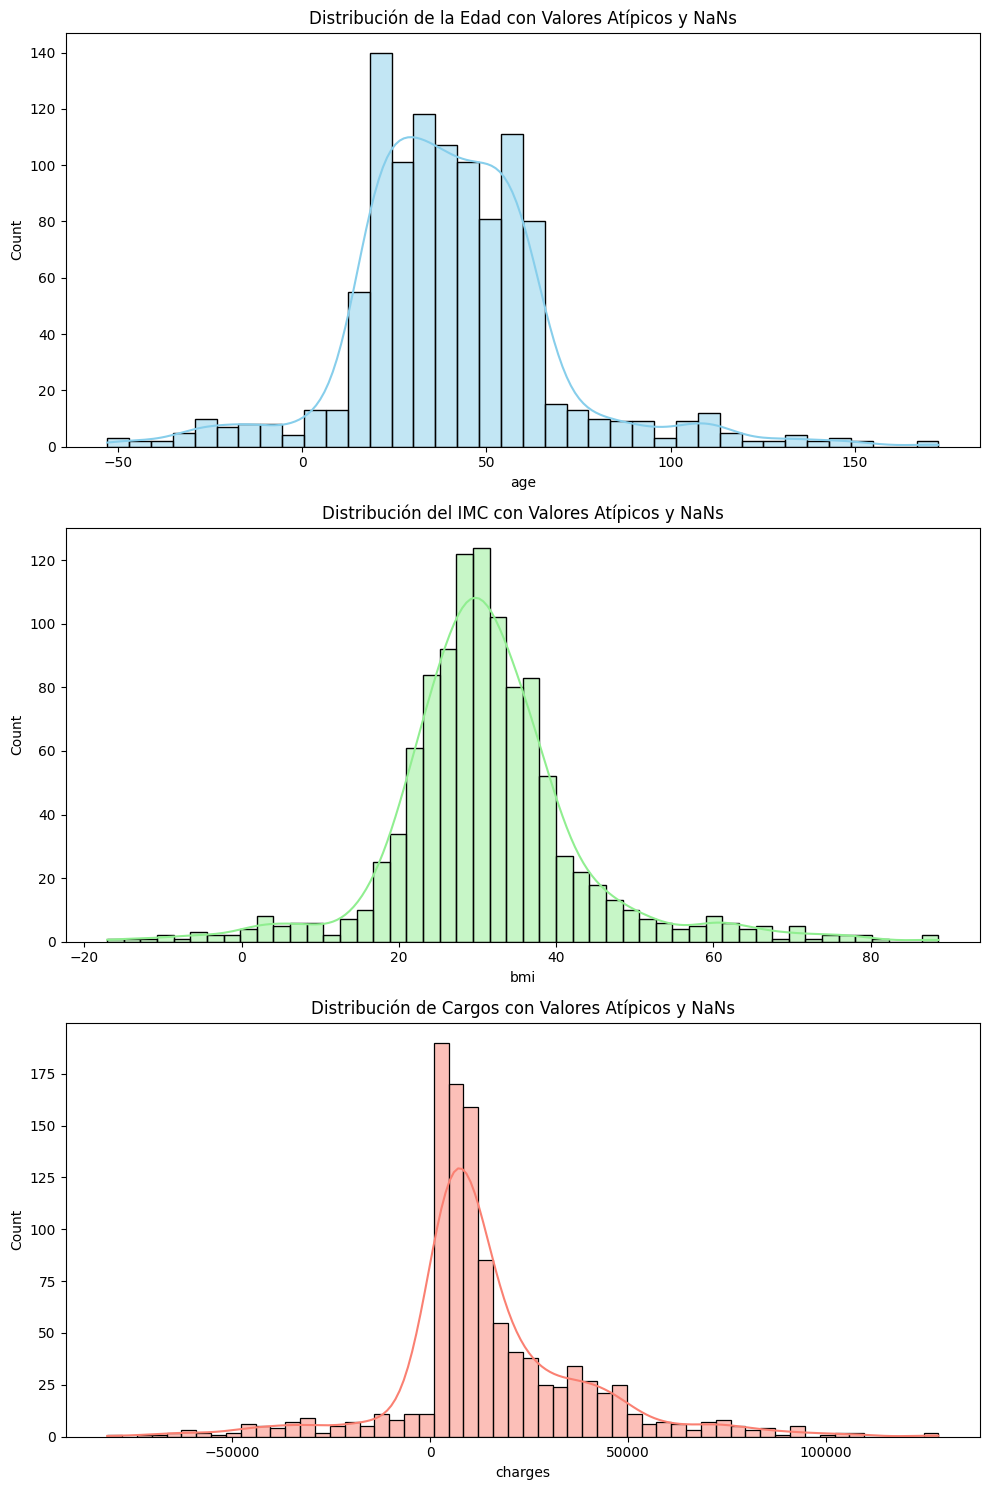

In [8]:
# Visualización de los datos con histogramas
fig, axes = plt.subplots(3, 1, figsize=(10, 15))
sns.histplot(data['age'].dropna(), kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de la Edad con Valores Atípicos y NaNs')
sns.histplot(data['bmi'].dropna(), kde=True, ax=axes[1], color='lightgreen')
axes[1].set_title('Distribución del IMC con Valores Atípicos y NaNs')
sns.histplot(data['charges'].dropna(), kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Distribución de Cargos con Valores Atípicos y NaNs')
plt.tight_layout()
plt.show()